In [1]:
#Check if python version is >= 3.7
import sys
assert sys.version_info >= (3, 7)

#Check if sklearn version is >= 1.0.1
from packaging import version
import sklearn
assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

In [2]:
#Figure settings
import matplotlib.pyplot as plt

plt.rc('font', size=12)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=12)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

In [3]:
#set the seed parameter of random number generator for reproducability of the results
import numpy as np
np.random.seed(42)

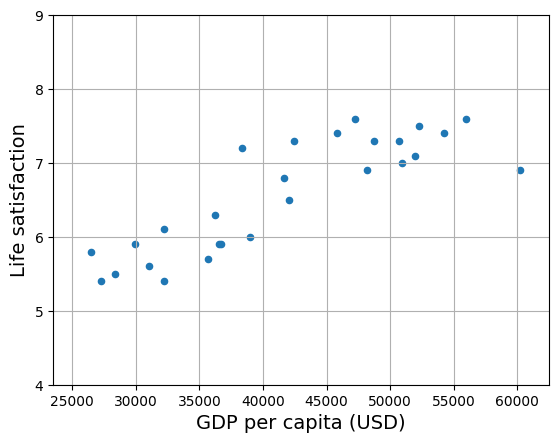

[[6.30165767]]


In [4]:
#Import libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

# Load the data
lifesat = pd.read_csv("/kaggle/input/datasets/zaferaydin/lifesat/lifesat.csv")
lifesat_full = pd.read_csv("/kaggle/input/datasets/zaferaydin/lifesat/lifesat_full.csv")

X = lifesat[["GDP per capita (USD)"]].values
y = lifesat[["Life satisfaction"]].values

# Visualize the data
lifesat.plot(kind='scatter', grid=True,
             x="GDP per capita (USD)", y="Life satisfaction")
plt.axis([23_500, 62_500, 4, 9])
plt.show()

# Select a linear model
model = LinearRegression()

# Train the model
model.fit(X, y)

# Make a prediction for Cyprus
X_new = [[37_655.2]]  # Cyprus' GDP per capita in 2020
print(model.predict(X_new)) # outputs [[6.30165767]]

In [5]:
#print the pandas dataframe that includes country, GDP per capita and life satisfaction info 
print(lifesat)

           Country  GDP per capita (USD)  Life satisfaction
0           Russia          26456.387938                5.8
1           Greece          27287.083401                5.4
2           Turkey          28384.987785                5.5
3           Latvia          29932.493910                5.9
4          Hungary          31007.768407                5.6
5         Portugal          32181.154537                5.4
6           Poland          32238.157259                6.1
7          Estonia          35638.421351                5.7
8            Spain          36215.447591                6.3
9         Slovenia          36547.738956                5.9
10       Lithuania          36732.034744                5.9
11          Israel          38341.307570                7.2
12           Italy          38992.148381                6.0
13  United Kingdom          41627.129269                6.8
14          France          42025.617373                6.5
15     New Zealand          42404.393738

In [6]:
print(lifesat_full)

           Country  GDP per capita (USD)  Life satisfaction
0     South Africa          11466.189672                4.7
1         Colombia          13441.492952                6.3
2           Brazil          14063.982505                6.4
3           Mexico          17887.750736                6.5
4            Chile          23324.524751                6.5
5           Russia          26456.387938                5.8
6           Greece          27287.083401                5.4
7           Turkey          28384.987785                5.5
8           Latvia          29932.493910                5.9
9          Hungary          31007.768407                5.6
10        Portugal          32181.154537                5.4
11          Poland          32238.157259                6.1
12         Estonia          35638.421351                5.7
13           Spain          36215.447591                6.3
14        Slovenia          36547.738956                5.9
15       Lithuania          36732.034744

In [7]:
import numpy as np

turkey_gdp = [[28384.987785]]
turkey_pred = model.predict(turkey_gdp)

turkey_pred

array([[5.67323928]])

In [8]:
lifesat[lifesat["Country"] == "Turkey"]

,Country,GDP per capita (USD),Life satisfaction
2,Turkey,28384.987785,5.5


In [9]:
true_value = 5.5  
abs(turkey_pred[0][0] - true_value)

np.float64(0.17323927757306734)

### Question 1 – Turkey (lifesat, Linear Regression)

Predicted life satisfaction: 5.67323928 
True life satisfaction: 5.5  
Absolute error: 0.17323927757306734

In [10]:
lifesat[lifesat["Country"] == "United States"]

,Country,GDP per capita (USD),Life satisfaction
26,United States,60235.728492,6.9


In [11]:
us_gdp = [[60235.728492]]
us_pred = model.predict(us_gdp)
us_pred

array([[7.83236904]])

In [12]:
true_value = 6.9 
abs(true_value - turkey_pred[0][0] )

np.float64(1.226760722426933)

### Question 2 – US (lifesat, Linear Regression)

Predicted life satisfaction: 7.83236904
True life satisfaction: 6.9
Absolute error: 1.226760722426933

In [13]:
lifesat_full[lifesat_full["Country"] == "Luxembourg"]

,Country,GDP per capita (USD),Life satisfaction
35,Luxembourg,110261.157353,6.9


In [14]:
lux_gdp = [[6.9]]
lux_pred = model.predict(lux_gdp)
print(lux_pred)

[[3.74951717]]


In [15]:
true_value = 6.9 
abs(lux_pred[0][0] - true_value)

np.float64(3.1504828285441815)

### Question 3 – Luxemburg (lifesat, Linear Regression)

Predicted life satisfaction: 3.74951717
True life satisfaction: 6.9
Absolute error: 3.1504828285441815

Question - 4
The linear regression model fails to provide accurate predictions for nations that maintain exceptionally high gross domestic product values which include Luxembourg. 
The model works reasonably for mid-range countries but struggles for extreme values. 
The data indicates that GDP and life satisfaction maintain an imperfect linear relationship.

In [16]:
from sklearn.linear_model import LinearRegression

X_full = lifesat_full[["GDP per capita (USD)"]]
y_full = lifesat_full[["Life satisfaction"]]

model_full = LinearRegression()
model_full.fit(X_full, y_full)

LinearRegression()

In [17]:
import pandas as pd

results = []

countries = ["Turkey", "United States", "Luxembourg"]

for country in countries:
    gdp = lifesat_full[lifesat_full["Country"] == country]["GDP per capita (USD)"].values[0]
    true_value = lifesat_full[lifesat_full["Country"] == country]["Life satisfaction"].values[0]
    
    prediction = model_full.predict([[gdp]])[0][0]
    abs_error = abs(prediction - true_value)
    
    results.append([country, prediction, true_value, abs_error])

results_df = pd.DataFrame(results, columns=["Country", "Predicted", "True", "Absolute Error"])
results_df

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


,Country,Predicted,True,Absolute Error
0,Turkey,6.242720,5.5,0.742720
1,United States,6.986143,6.9,0.086143
2,Luxembourg,8.153780,6.9,1.253780


Question 5 - Linear Regression using lifesat_full

Turkey:
Predicted: 6.2427
True: 5.5000
Absolute Error: 0.7427

United States:
Predicted: 6.9861
True: 6.9000
Absolute Error: 0.0861

Luxembourg:
Predicted: 8.1538
True: 6.9000
Absolute Error: 1.2538

In [18]:
from sklearn.linear_model import Ridge
import pandas as pd

# Train Ridge using lifesat
X = lifesat[["GDP per capita (USD)"]]
y = lifesat[["Life satisfaction"]]

ridge = Ridge(alpha=10**9.5)
ridge.fit(X, y)

results = []

# --- Turkey & US from lifesat ---
for country in ["Turkey", "United States"]:
    
    row = lifesat[lifesat["Country"] == country]
    
    gdp = row["GDP per capita (USD)"].values[0]
    true_value = row["Life satisfaction"].values[0]
    
    prediction = ridge.predict([[gdp]]).item()
    abs_error = abs(prediction - true_value)
    
    results.append([country, prediction, true_value, abs_error])

# --- Luxembourg from lifesat_full ---
lux_row = lifesat_full[lifesat_full["Country"] == "Luxembourg"]

lux_gdp = lux_row["GDP per capita (USD)"].values[0]
lux_true = lux_row["Life satisfaction"].values[0]

lux_prediction = ridge.predict([[lux_gdp]]).item()
lux_error = abs(lux_prediction - lux_true)

results.append(["Luxembourg", lux_prediction, lux_true, lux_error])

# Create table
results_df = pd.DataFrame(results, 
                          columns=["Country", "Predicted", "True", "Absolute Error"])

print("### Ridge Regression Results\n")
display(results_df)


### Ridge Regression Results



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(


,Country,Predicted,True,Absolute Error
0,Turkey,6.180089,5.5,0.680089
1,United States,7.114324,6.9,0.214324
2,Luxembourg,8.581652,6.9,1.681652


Yes, Ridge regression provides better predictions for both the US and Luxembourg.

For the US, the absolute error decreased significantly 
(from 1.2268 to 0.2143), showing a major improvement.

For Luxembourg, the absolute error also decreased 
(from 3.1505 to 1.6817). Although the prediction is still not very accurate, 
Ridge regression improves stability and reduces overfitting compared to standard linear regression.

However, Luxembourg remains difficult to predict accurately 
because it lies outside the main GDP range of the training data (extrapolation problem).

In [19]:
from sklearn.neighbors import KNeighborsRegressor
import pandas as pd

# Train KNN using lifesat
X = lifesat[["GDP per capita (USD)"]]
y = lifesat[["Life satisfaction"]]

knn = KNeighborsRegressor(n_neighbors=3)
knn.fit(X, y)

results = []

# --- Turkey & US from lifesat ---
for country in ["Turkey", "United States"]:
    
    row = lifesat[lifesat["Country"] == country]
    
    gdp = row["GDP per capita (USD)"].values[0]
    true_value = row["Life satisfaction"].values[0]
    
    prediction = knn.predict([[gdp]]).item()
    abs_error = abs(prediction - true_value)
    
    results.append([country, prediction, true_value, abs_error])

# --- Luxembourg from lifesat_full ---
lux_row = lifesat_full[lifesat_full["Country"] == "Luxembourg"]

lux_gdp = lux_row["GDP per capita (USD)"].values[0]
lux_true = lux_row["Life satisfaction"].values[0]

lux_prediction = knn.predict([[lux_gdp]]).item()
lux_error = abs(lux_prediction - lux_true)

results.append(["Luxembourg", lux_prediction, lux_true, lux_error])

# Create result table
results_df = pd.DataFrame(results, 
                          columns=["Country", "Predicted", "True", "Absolute Error"])

print("### K-Nearest Neighbors (k=3) Results\n")
display(results_df)

print("\nEvaluation:")
print("KNN does not assume a linear relationship between GDP and life satisfaction.")
print("It makes predictions based on nearby countries in GDP space.")
print("However, for extreme GDP values such as Luxembourg, predictions may still be unstable.")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


### K-Nearest Neighbors (k=3) Results



,Country,Predicted,True,Absolute Error
0,Turkey,5.6,5.5,0.1
1,United States,7.3,6.9,0.4
2,Luxembourg,7.3,6.9,0.4



Evaluation:
KNN does not assume a linear relationship between GDP and life satisfaction.
It makes predictions based on nearby countries in GDP space.
However, for extreme GDP values such as Luxembourg, predictions may still be unstable.
